# Group 4 · Project — Transformer HAR: Attention vs Recurrence on Real Sensor Data

The Group 3 project ranked four recurrent cells on UCI HAR (RNN 0.797, LSTM 0.896,
Bi-LSTM 0.904, GRU 0.908) and showed the plain RNN starved its early timesteps.
This project drops recurrence entirely: a Transformer encoder, built from the
scratch components of Labs A and B, classifies the same 128-timestep sensor
windows. Same data, same task, same split -- an apples-to-apples test of whether
attention beats (or matches) recurrence here.

**Deliverables.** (1) Transformer test accuracy placed directly beside the Group 3
recurrent numbers. (2) An attention map over the 128 timesteps -- which part of the
motion window the classifier actually looks at, per activity -- which recurrent
models cannot give you.

**Colab discipline.** Checkpoint to Drive every epoch, resumable (same as Group 3).

In [3]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, random, os, glob, zipfile, urllib.request, math
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

CHECKPOINT_DIR = '/content/drive/MyDrive/har_project'    # reuse Group 3 location (data cached here)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

def seed_all(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device: cuda


In [4]:
DATASET_URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
CACHED_DATASET_DIR = os.path.join(CHECKPOINT_DIR, "UCI HAR Dataset")
WORK_DIR = "/content/har"; os.makedirs(WORK_DIR, exist_ok=True)

def find_data_root(search_root):
    for current_dir, subdirs, _ in os.walk(search_root):
        if "train" in subdirs and "test" in subdirs:
            return current_dir
    return None

data_root = find_data_root(CACHED_DATASET_DIR) if os.path.isdir(CACHED_DATASET_DIR) else None
if data_root is None:
    print("downloading UCI HAR (~58 MB)...")
    outer_zip = os.path.join(WORK_DIR, "outer.zip")
    urllib.request.urlretrieve(DATASET_URL, outer_zip)
    with zipfile.ZipFile(outer_zip) as archive:
        archive.extractall(WORK_DIR)
    for inner_zip in glob.glob(os.path.join(WORK_DIR, "**", "*.zip"), recursive=True):
        with zipfile.ZipFile(inner_zip) as archive:
            archive.extractall(os.path.dirname(inner_zip))
    data_root = find_data_root(WORK_DIR)
    if data_root and not os.path.isdir(CACHED_DATASET_DIR):
        import shutil
        shutil.copytree(data_root, CACHED_DATASET_DIR)
        data_root = find_data_root(CACHED_DATASET_DIR)

SIGNAL_NAMES = ["body_acc_x", "body_acc_y", "body_acc_z",
                "body_gyro_x", "body_gyro_y", "body_gyro_z",
                "total_acc_x", "total_acc_y", "total_acc_z"]

def load_split(split):
    signal_dir = os.path.join(data_root, split, "Inertial Signals")
    channels = [np.loadtxt(os.path.join(signal_dir, f"{name}_{split}.txt")) for name in SIGNAL_NAMES]
    features = np.stack(channels, axis=-1)                                      # (N, 128, 9)
    labels = np.loadtxt(os.path.join(data_root, split, f"y_{split}.txt")).astype(int) - 1
    return torch.tensor(features, dtype=torch.float32), torch.tensor(labels, dtype=torch.long)

X_train, y_train = load_split("train")
X_test, y_test = load_split("test")
print("train:", X_train.shape, " test:", X_test.shape, " classes:", y_train.unique().tolist())

train: torch.Size([7352, 128, 9])  test: torch.Size([2947, 128, 9])  classes: [0, 1, 2, 3, 4, 5]


In [5]:
channel_mean = X_train.mean(dim=(0, 1), keepdim=True)
channel_std = X_train.std(dim=(0, 1), keepdim=True) + 1e-6

X_train = ((X_train - channel_mean) / channel_std).to(device); y_train = y_train.to(device)
X_test = ((X_test - channel_mean) / channel_std).to(device); y_test = y_test.to(device)
print("normalized -> mean:", float(X_train.mean()), " std:", float(X_train.std()))

normalized -> mean: 8.618927793691e-09  std: 0.9999951124191284


## The architecture

We reuse the exact components built by hand in Lab B -- sinusoidal positional
encoding, multi-head self-attention, and the Transformer block -- and wrap them
into an encoder for continuous sensor input:

- A linear projection lifts the 9 sensor channels to the model dimension (there is
  no token embedding here; the input is already continuous).
- A learnable CLS token is prepended; positional encoding is added.
- N Transformer blocks process the sequence.
- The CLS token's final representation is classified. Its attention over the 128
  timesteps is our saliency map.

In [6]:
def positional_encoding(seq_len, model_dim):
    positions = torch.arange(seq_len).unsqueeze(1).float()          # (seq_len, 1)
    dim_indices = torch.arange(model_dim).unsqueeze(0).float()      # (1, model_dim)
    angles = positions / torch.pow(10000, (2 * (dim_indices // 2)) / model_dim)
    encoding = torch.zeros(seq_len, model_dim)
    encoding[:, 0::2] = torch.sin(angles[:, 0::2])                  # even dims: sine
    encoding[:, 1::2] = torch.cos(angles[:, 1::2])                  # odd dims: cosine
    return encoding

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, model_dim, num_heads):
        super().__init__()
        assert model_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = model_dim // num_heads
        self.query_proj = nn.Linear(model_dim, model_dim)
        self.key_proj = nn.Linear(model_dim, model_dim)
        self.value_proj = nn.Linear(model_dim, model_dim)
        self.output_proj = nn.Linear(model_dim, model_dim)
    def forward(self, x, return_attn=False):
        batch_size, seq_len, model_dim = x.shape
        def split_heads(tensor):                                    # (B,T,d) -> (B,heads,T,head_dim)
            return tensor.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        queries = split_heads(self.query_proj(x))
        keys = split_heads(self.key_proj(x))
        values = split_heads(self.value_proj(x))
        scores = queries @ keys.transpose(-2, -1) / math.sqrt(self.head_dim)
        attn_weights = F.softmax(scores, dim=-1)                    # (B, heads, T, T)
        attended = attn_weights @ values                           # (B, heads, T, head_dim)
        attended = attended.transpose(1, 2).contiguous().view(batch_size, seq_len, model_dim)
        output = self.output_proj(attended)
        return (output, attn_weights) if return_attn else output

class TransformerBlock(nn.Module):
    def __init__(self, model_dim, num_heads, feedforward_dim=128):
        super().__init__()
        self.attention = MultiHeadSelfAttention(model_dim, num_heads)
        self.norm1 = nn.LayerNorm(model_dim)
        self.norm2 = nn.LayerNorm(model_dim)
        self.feed_forward = nn.Sequential(
            nn.Linear(model_dim, feedforward_dim), nn.ReLU(),
            nn.Linear(feedforward_dim, model_dim))
    def forward(self, x):
        x = self.norm1(x + self.attention(x))      # attention sub-layer + residual + norm
        x = self.norm2(x + self.feed_forward(x))   # feed-forward sub-layer + residual + norm
        return x
    def attention_weights(self, x):
        _, weights = self.attention(x, return_attn=True)
        return weights

In [7]:
class HARTransformer(nn.Module):
    def __init__(self, num_channels=9, model_dim=64, num_heads=4, num_blocks=2,
                 num_classes=6, seq_len=128):
        super().__init__()
        self.input_proj = nn.Linear(num_channels, model_dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, model_dim) * 0.02)
        self.register_buffer("pos_encoding", positional_encoding(seq_len + 1, model_dim))
        self.blocks = nn.ModuleList([TransformerBlock(model_dim, num_heads) for _ in range(num_blocks)])
        self.classifier = nn.Linear(model_dim, num_classes)
    def forward(self, x, return_attn=False):
        batch_size = x.size(0)
        hidden = self.input_proj(x)                                        # (B, T, d)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        hidden = torch.cat([cls_tokens, hidden], dim=1) + self.pos_encoding.unsqueeze(0)
        last_block_attention = None
        for block_index, block in enumerate(self.blocks):
            if return_attn and block_index == len(self.blocks) - 1:
                last_block_attention = block.attention_weights(hidden)     # (B, heads, T+1, T+1)
            hidden = block(hidden)
        logits = self.classifier(hidden[:, 0])                             # classify from CLS token
        if return_attn:
            cls_to_timesteps = last_block_attention[:, :, 0, 1:].mean(dim=1)   # (B, T), avg over heads
            return logits, cls_to_timesteps
        return logits

In [8]:
def train_transformer(seed=0, num_epochs=20, learning_rate=1e-3, batch_size=64, resume=True):
    seed_all(seed)
    model = HARTransformer().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.CrossEntropyLoss()
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"har_transformer_seed{seed}.pt")
    start_epoch = 0
    history = {"train_loss": [], "test_acc": []}

    if resume and os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint["model"]); optimizer.load_state_dict(checkpoint["optimizer"])
        start_epoch = checkpoint["epoch"] + 1; history = checkpoint["history"]
        if start_epoch >= num_epochs:
            print(f"already done (acc={history['test_acc'][-1]:.3f})"); return model, history
        print(f"resuming from epoch {start_epoch}")

    for epoch in range(start_epoch, num_epochs):
        model.train()
        permutation = torch.randperm(X_train.size(0))
        total_loss, num_batches = 0.0, 0
        for batch_start in range(0, X_train.size(0), batch_size):
            batch_indices = permutation[batch_start:batch_start + batch_size]
            optimizer.zero_grad()
            loss = loss_fn(model(X_train[batch_indices]), y_train[batch_indices])
            loss.backward(); optimizer.step()
            total_loss += loss.item(); num_batches += 1
        model.eval()
        with torch.no_grad():
            test_accuracy = (model(X_test).argmax(1) == y_test).float().mean().item()
        history["train_loss"].append(total_loss / num_batches)
        history["test_acc"].append(test_accuracy)
        torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(),
                    "epoch": epoch, "history": history}, checkpoint_path)
        print(f"epoch {epoch:2d}: loss={total_loss / num_batches:.3f}  test_acc={test_accuracy:.3f}")
    return model, history

transformer_model, history = train_transformer()

epoch  0: loss=0.503  test_acc=0.872
epoch  1: loss=0.147  test_acc=0.868
epoch  2: loss=0.144  test_acc=0.899
epoch  3: loss=0.127  test_acc=0.887
epoch  4: loss=0.116  test_acc=0.882
epoch  5: loss=0.111  test_acc=0.894
epoch  6: loss=0.106  test_acc=0.884
epoch  7: loss=0.108  test_acc=0.872
epoch  8: loss=0.114  test_acc=0.897
epoch  9: loss=0.118  test_acc=0.889
epoch 10: loss=0.102  test_acc=0.900
epoch 11: loss=0.097  test_acc=0.900
epoch 12: loss=0.090  test_acc=0.912
epoch 13: loss=0.091  test_acc=0.901
epoch 14: loss=0.086  test_acc=0.912
epoch 15: loss=0.077  test_acc=0.913
epoch 16: loss=0.082  test_acc=0.901
epoch 17: loss=0.083  test_acc=0.893
epoch 18: loss=0.073  test_acc=0.902
epoch 19: loss=0.082  test_acc=0.907


In [9]:
group3_results = {"SimpleRNN": 0.797, "LSTM": 0.896, "Bi-LSTM": 0.904, "GRU": 0.908}
transformer_best_acc = max(history["test_acc"])

print(f"{'model':12s} {'best test acc':>14s}")
print("-" * 28)
for model_name, accuracy in sorted(group3_results.items(), key=lambda item: item[1]):
    print(f"{model_name:12s} {accuracy:>14.3f}")
print(f"{'Transformer':12s} {transformer_best_acc:>14.3f}   <- this project")

model         best test acc
----------------------------
SimpleRNN             0.797
LSTM                  0.896
Bi-LSTM               0.904
GRU                   0.908
Transformer           0.913   <- this project


## Part 2 - What does the model look at? Attention over the motion window

The recurrent models gave us a number; the Transformer also gives us a window into
its reasoning. The CLS token's attention over the 128 timesteps is a saliency map:
how much the classifier's decision drew on each moment of the motion window. We
average this map over all test examples of each activity, so we can ask whether the
model attends differently depending on what it is classifying -- for instance,
whether dynamic activities (walking) spread attention across the periodic stride
pattern while static postures (sitting, standing, laying) concentrate it.

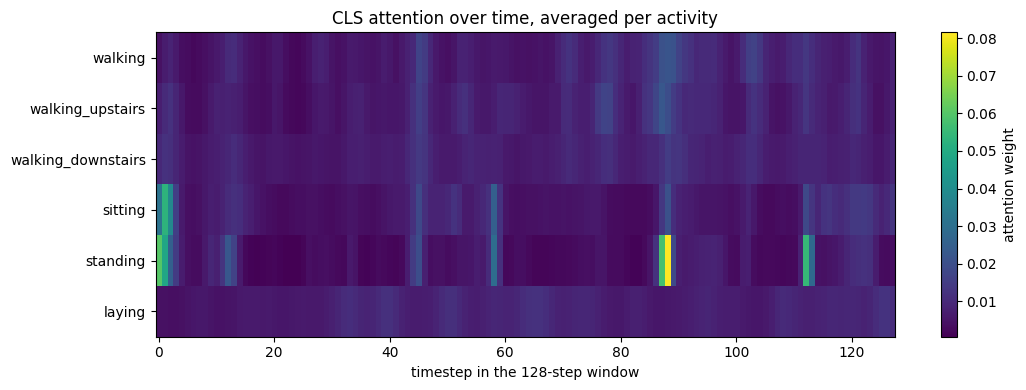

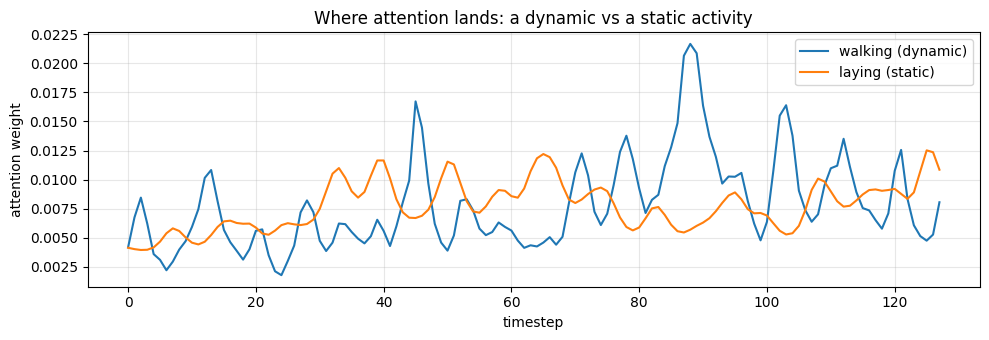

In [10]:
activity_names = ["walking", "walking_upstairs", "walking_downstairs",
                  "sitting", "standing", "laying"]

transformer_model.eval()
attention_chunks = []
with torch.no_grad():
    for batch_start in range(0, X_test.size(0), 512):
        _, attention_batch = transformer_model(X_test[batch_start:batch_start + 512], return_attn=True)
        attention_chunks.append(attention_batch.cpu())
attention_maps = torch.cat(attention_chunks, dim=0)           # (N_test, 128)
test_labels = y_test.cpu()

per_class_attention = torch.stack([
    attention_maps[test_labels == class_id].mean(dim=0) for class_id in range(6)
])                                                            # (6, 128)

# heatmap: activities x timesteps
fig, ax = plt.subplots(figsize=(11, 4))
heatmap = ax.imshow(per_class_attention.numpy(), aspect="auto", cmap="viridis")
ax.set_yticks(range(6)); ax.set_yticklabels(activity_names)
ax.set_xlabel("timestep in the 128-step window")
ax.set_title("CLS attention over time, averaged per activity")
fig.colorbar(heatmap, ax=ax, label="attention weight")
plt.tight_layout(); plt.show()

# contrast one dynamic vs one static activity
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(per_class_attention[0], label="walking (dynamic)")
ax.plot(per_class_attention[5], label="laying (static)")
ax.set_xlabel("timestep"); ax.set_ylabel("attention weight")
ax.set_title("Where attention lands: a dynamic vs a static activity")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Project - concept check

**Q1. The Transformer reached 0.913, just above GRU's 0.908, despite Transformers
usually being described as "data-hungry" and this dataset being small (7,352
training windows). Why did it do well here, and what does that say about the
"Transformers need huge data" claim?**

The claim is about scale relative to task difficulty, not an absolute rule. The
"data-hungry" reputation comes from large language and vision models that must learn
rich, general representations from scratch, where attention's weak inductive biases
(no built-in locality or order) mean it needs a great deal of data to discover
structure that a CNN or RNN assumes for free. HAR is a comparatively easy, narrow
task: six physically distinct activities, short fixed-length windows, and strong
low-level cues (periodicity for walking, gravity direction for the static postures).
A small two-block encoder has more than enough signal to separate them, and the
positional encoding plus the CLS pooling supply the bit of order-awareness the task
needs. So the result is consistent with the claim rather than a counterexample: on a
small, well-posed problem a small Transformer is enough, and the data-hungriness only
bites when the representation to be learned is large and general.

**Q2. The Transformer and the Group 3 recurrent models reach similar accuracy, yet we
still call the Transformer the more capable architecture here. On what axes other than
accuracy does it win, and is there an axis on which the RNNs win?**

On this dataset accuracy is nearly tied, so the differences are elsewhere. The
Transformer trains in parallel across timesteps -- there is no sequential dependency
to unroll -- so it uses the GPU more fully and scales better to longer sequences,
and every position reaches every other in one hop, so there is no vanishing gradient
over distance (the exact failure the Group 3 project measured in the RNN). It is also
interpretable: the attention map shows which timesteps drove the decision, which the
recurrent models cannot provide directly. The RNNs win on efficiency at this scale:
their compute is linear in sequence length while self-attention is quadratic, and for
short 128-step windows with limited data their stronger sequential inductive bias
makes them smaller and faster to train to the same accuracy. The honest summary is
that the Transformer is the more scalable and more interpretable choice, while the
RNN is the leaner choice when sequences are short and data is limited.

**Q3. The attention saliency is read from the CLS token's weights. What exactly does
that map show, what does it NOT show, and what is one way it could mislead you?**

It shows, for each timestep, how much weight the CLS token placed on that timestep in
the final block's attention when forming the representation that was then classified --
a measure of where the pooled decision vector drew its information from. It does not
show a causal account of the prediction: attention weight is correlation between the
CLS query and each timestep's key, not a guarantee that those timesteps changed the
output, and information from unattended timesteps can still reach the CLS token
indirectly through earlier blocks that already mixed positions. It could mislead by
making the model look like it focuses sharply on a few timesteps when the real
computation was distributed: because we averaged over heads and over examples, a clean
peak might be an averaging artifact, and because residual connections let the CLS token
carry information forward without re-attending, low attention on a timestep does not
mean that timestep was irrelevant. Attention maps are a useful hint about the model's
behavior, not a faithful explanation of it -- a caution that applies to interpreting
real Transformers as much as to this one.